# py-SCORPIUS — Tutorial on simulated data

Walkthrough of every public function in `pyscorpius` on a synthetic linear-trajectory dataset.

Follows the 7-section schema from [`omicverse-rebuildr/NOTEBOOKS.md`](https://github.com/omicverse/omicverse-rebuildr/blob/main/NOTEBOOKS.md).

## 1. What this package does

`pyscorpius` is a pure-Python port of [SCORPIUS](https://github.com/rcannood/SCORPIUS) (Cannoodt et al., bioRxiv 2016) — **linear** trajectory inference for single-cell RNA-seq. It infers one ordering of cells along a continuous pseudotime via:

1. **Pairwise distance** (Spearman by default)
2. **Classical MDS** to a low-dim space
3. **K-means** clustering + **TSP** through cluster centres → initial trajectory
4. **Hastie-Stuetzle** principal curve refinement → final pseudotime
5. (Optional) **Module extraction** via `py-mclustR` Mclust
6. (Optional) **Gene importance** via sklearn random-forest regression

**Input**: a `cells × genes` expression matrix.
**Output**: per-cell pseudotime + low-dim space + (optional) gene modules / importance ranking.

**Citation**: Cannoodt, R. et al. *SCORPIUS improves trajectory inference and identifies novel modules in dendritic cell development.* bioRxiv 079509 (2016).

## 2. Install + import

In [1]:
# pip install pyscorpius
import sys
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_traj_dev/py-SCORPIUS')
import pyscorpius
from pyscorpius import reduce_dimensionality, infer_trajectory, extract_modules, gene_importances
print(f'pyscorpius version: {pyscorpius.__version__}')

pyscorpius version: 0.1.0


## 3. Load demo data

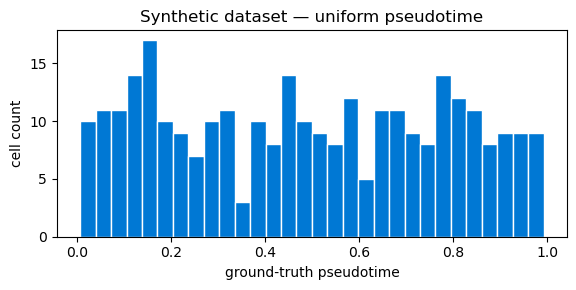

expression shape: (300, 80)  (cells × genes)


In [2]:
import numpy as np
rng = np.random.default_rng(42)
n_cells, n_genes = 300, 80
pt_true = np.sort(rng.uniform(0, 1, n_cells))

# Cells × genes; 60 of 80 genes correlate with pt_true (4 distinct patterns)
expression = rng.normal(0, 0.5, (n_cells, n_genes))
for g in range(60):
    pattern = g % 4
    if pattern == 0: expression[:, g] += 3 * pt_true
    elif pattern == 1: expression[:, g] += 3 * (1 - pt_true)
    elif pattern == 2: expression[:, g] += 3 * np.sin(np.pi * pt_true)
    else: expression[:, g] += 3 * (pt_true > 0.5).astype(float)

# Plot ground-truth pseudotime distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pt_true, bins=30, color='#0078d4', edgecolor='white')
ax.set_xlabel('ground-truth pseudotime'); ax.set_ylabel('cell count')
ax.set_title('Synthetic dataset — uniform pseudotime')
plt.tight_layout(); plt.show()

print(f'expression shape: {expression.shape}  (cells × genes)')

## 4. Public functions

### 4.1 `reduce_dimensionality(x, dist, ndim, num_landmarks)`

R: `reduce_dimensionality(x, dist=c('spearman',...), ndim=3, num_landmarks=1000)`

Computes pairwise distances + classical MDS to a low-dim coordinate space.

space shape: (300, 2)


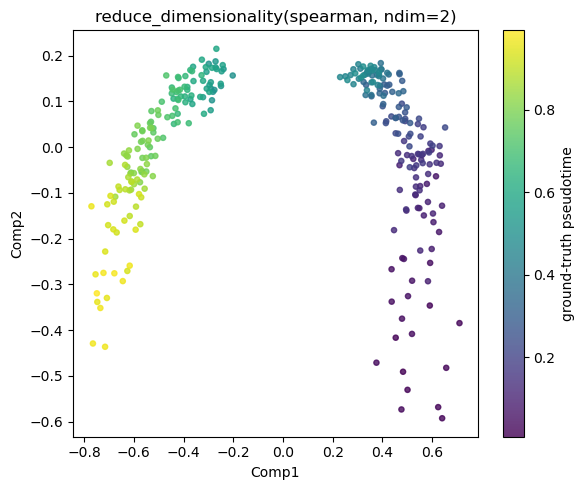

In [3]:
space = reduce_dimensionality(expression, dist='spearman', ndim=2)
print(f'space shape: {space.shape}')

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(space[:, 0], space[:, 1], c=pt_true, cmap='viridis', s=14, alpha=0.8)
plt.colorbar(sc, label='ground-truth pseudotime')
ax.set_xlabel('Comp1'); ax.set_ylabel('Comp2')
ax.set_title("reduce_dimensionality(spearman, ndim=2)")
plt.tight_layout(); plt.show()

### 4.2 `infer_trajectory(space, k)`

R: `infer_trajectory(space, k=4)`

K-means → TSP-ordered cluster centers (initial path) → Hastie-Stuetzle principal-curve refinement.

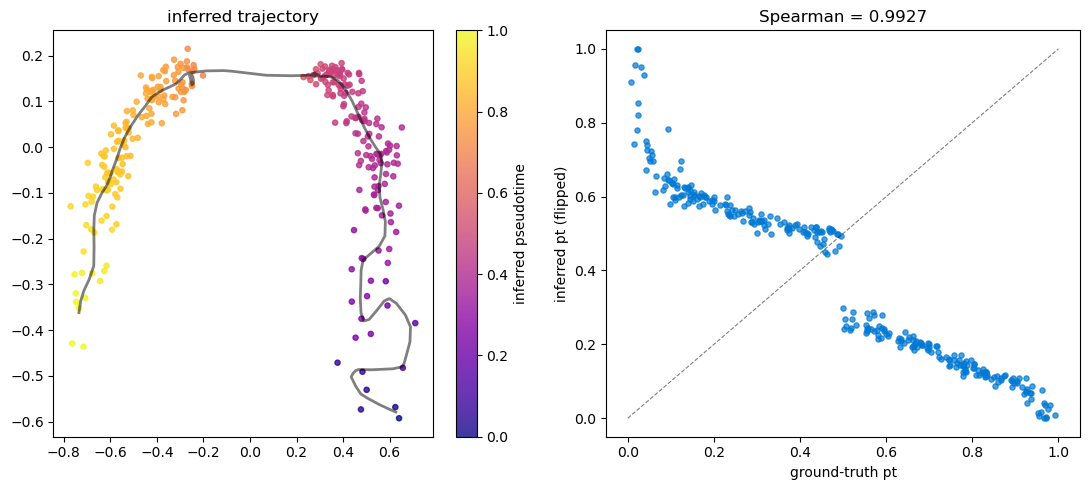

In [4]:
traj = infer_trajectory(space, k=4)
pseudotime = traj['time']
curve = traj['path']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
sc = ax1.scatter(space[:, 0], space[:, 1], c=pseudotime, cmap='plasma', s=14, alpha=0.8)
ax1.plot(curve[:, 0], curve[:, 1], 'k-', lw=2, alpha=0.5)
plt.colorbar(sc, ax=ax1, label='inferred pseudotime')
ax1.set_title('inferred trajectory')

from scipy.stats import spearmanr
fwd = spearmanr(pseudotime, pt_true)[0]
rev = spearmanr(1 - pseudotime, pt_true)[0]
sign = 1 if abs(fwd) > abs(rev) else -1
flipped = pseudotime if sign == 1 else 1 - pseudotime
ax2.scatter(pt_true, flipped, s=14, alpha=0.7, color='#0078d4')
ax2.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.5)
ax2.set_xlabel('ground-truth pt'); ax2.set_ylabel('inferred pt' + ('' if sign==1 else ' (flipped)'))
ax2.set_title(f"Spearman = {max(abs(fwd), abs(rev)):.4f}")
plt.tight_layout(); plt.show()

### 4.3 `extract_modules(expression, pseudotime, n_modules_range)`

R: `extract_modules(...)` — Mclust on smoothed expression-vs-pseudotime.

Requires `pyscorpius[modules]` (pulls in `pymclustR ≥ 0.2.0`).

In [5]:
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_dev/py-mclustR')
mods = extract_modules(expression.T, pseudotime, n_modules_range=range(2, 6))
print(f"selected n_modules: {mods['n_modules']}  BIC={mods['bic']:.2f}")
print(f"module sizes: {np.bincount(mods['module'])[1:]}")

selected n_modules: 5  BIC=nan
module sizes: [32 16 18  6  8]


### 4.4 `gene_importances(expression, pseudotime, n_trees)`

R: `gene_importances(...)` — random-forest feature importance.

(R uses `ranger`; Python uses `sklearn.ensemble.RandomForestRegressor`.)

In [6]:
imp = gene_importances(expression.T, pseudotime, n_trees=300, seed=42,
                       gene_names=[f'Gene_{i+1}' for i in range(n_genes)])
print('Top 10 most important genes:')
print(imp.head(10).to_string())
print(f"\nOf the 60 genes injected with pseudotime signal, {sum(1 for g in imp.head(60).index if int(g.split('_')[1]) <= 60)}/60 are in the top-60 by importance.")

Top 10 most important genes:
         importance  rank
Gene_52    0.147935     1
Gene_48    0.111921     2
Gene_4     0.076670     3
Gene_32    0.071108     4
Gene_20    0.068421     5
Gene_12    0.062964     6
Gene_47    0.056257     7
Gene_16    0.045741     8
Gene_24    0.042969     9
Gene_60    0.042785    10

Of the 60 genes injected with pseudotime signal, 51/60 are in the top-60 by importance.


## 5. Class-API: (deferred to v0.2)

pyscorpius v0.1 ships only the functional API. An AnnData-native class wrapper that writes results into `adata.obs` / `adata.obsm` is on the v0.2 roadmap. For now:

In [7]:
# Build an AnnData with the results — fully manual
import anndata as ad
import pandas as pd
adata = ad.AnnData(X=expression,
                   obs=pd.DataFrame({'pseudotime_true': pt_true,
                                     'pseudotime': pseudotime,
                                     'group': pd.Categorical([f'g{int(p*4)}' for p in pt_true])}),
                   var=pd.DataFrame(index=[f'Gene_{i+1}' for i in range(n_genes)]))
adata.obsm['X_scorpius'] = space
adata.uns['scorpius_path'] = curve
adata.var['scorpius_importance'] = imp.reindex(adata.var_names)['importance'].values
adata.var['scorpius_module'] = pd.Categorical(mods['module'])
print(adata)

AnnData object with n_obs × n_vars = 300 × 80
    obs: 'pseudotime_true', 'pseudotime', 'group'
    var: 'scorpius_importance', 'scorpius_module'
    uns: 'scorpius_path'
    obsm: 'X_scorpius'


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## 6. Common pitfalls / FAQ

- **Matrix orientation**: `reduce_dimensionality` + `gene_importances` expect `cells × genes`; `extract_modules` expects `genes × cells` (R `expression` convention). Don't mix.
- **Distance metric**: SCORPIUS default is `'spearman'`. For small-sample-size data with few zero counts, `'pearson'` is often noisier. Stick with Spearman unless you have a reason.
- **Direction is arbitrary**: pseudotime in [0, 1] but the direction is determined by the principal-curve init. Use ground-truth marker genes to orient. Or pass `infer_trajectory(..., flip=True)` once that's added (v0.2).
- **`k` (number of clusters)**: default 4. Higher k = more flexible init but slower; lower k = stiffer trajectory. For most scRNA-seq datasets k ∈ {3, 4, 5}.

## 7. Where to go next

- [`README.md`](../README.md) — install + quickstart
- [`RECONSTRUCTION_REPORT.md`](../RECONSTRUCTION_REPORT.md) — parity audit
- [`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb) — pipeline parity validation
- [`function_by_function_R_parity.ipynb`](function_by_function_R_parity.ipynb) — R⇄Python parameter dictionary
- [Upstream R SCORPIUS](https://github.com/rcannood/SCORPIUS) — Cannoodt et al. 2016
- [`omicverse-rebuildr`](https://github.com/omicverse/omicverse-rebuildr) — the protocol this port was built under